# Level 4 — 심층 분석: Grad-CAM 및 효율성 Trade-off

**목표**: 모델의 *동작 원리* 를 설명하고, FPS와 정확도의 trade-off 를 정량화합니다.

리포트 필수 산출물:
1. **속성별 정규화 Confusion Matrix 3개** — best 모델(ViT-S/16) 기준.
2. **Grad-CAM 패널** — 같은 이미지에 대해 3개 head 가 각각 어디를 보는지 시각화 (CNN: ResNet-18 / ViT: ViT-S/16 + Attention Rollout).
3. 모든 백본(VGG-16 / ResNet-18 / ResNet-50 / ViT-S/16)에 대한 **FPS vs Avg-MF1 Pareto plot**.

본 노트북은 **학습 없이 체크포인트(.pth)를 로드해 eval/시각화만 수행하는 분석 노트북**입니다 (Colab T4 `Run All` 재현 대상). FPS 측정 셀은 반드시 **T4 GPU 에서 실행**해야 채점이 유효합니다 (다른 GPU 의 FPS 는 참고용).

In [1]:
import os
import sys

# 1. 코랩 환경에서 레포지토리가 클론되지 않은 경우에만 Clone 진행
repo_name = "2026-HYU-AUE8088-PA2"
if not os.path.exists(f"/content/{repo_name}"):
    !git clone https://github.com/Leem1nwon/2026-HYU-AUE8088-PA2.git

# 2. 작업 디렉토리를 레포지토리의 최상단(Root)으로 변경
%cd /content/{repo_name}

%load_ext autoreload
%autoreload 2

# 의존성 설치 (이미 설치된 패키지는 빠르게 skip)
!pip install -q -r requirements.txt

Cloning into '2026-HYU-AUE8088-PA2'...
remote: Enumerating objects: 203, done.
remote: Counting objects: 100% (203/203), done.
remote: Compressing objects: 100% (156/156), done.
remote: Total 203 (delta 53), reused 194 (delta 44), pack-reused 0 (from 0)
Receiving objects: 100% (203/203), 8.42 MiB | 19.51 MiB/s, done.
Resolving deltas: 100% (53/53), done.
/content/2026-HYU-AUE8088-PA2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.8/26.8 MB 90.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 133.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 75.2 MB/s eta 0:00:00
   ━━━━━━━

In [2]:
import os, sys, zipfile, subprocess

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from src.utils.seed import set_seed
from src.utils.transforms import eval_transform, IMAGENET_MEAN, IMAGENET_STD
from src.utils.metrics import (
    collect_predictions, confusion_matrices, per_class_prf,
    average_macro_f1, per_attribute_macro_f1, CLASS_NAMES,
)
from src.utils.efficiency import count_parameters, count_flops, measure_fps
from src.datasets.bdd_attr import (
    BDDAttrDataset, ATTRIBUTES, NUM_CLASSES, WEATHER_CLASSES,
)
from src.xai.gradcam import GradCAM, ViTGradCAM, attention_rollout
# 모델은 본인 구현(src.models) 만 사용 — torchvision.models / timm import 금지.
from src.models.resnet import resnet18, resnet50
from src.models.vgg import VGG16
from src.models.vit import vit_small_patch16_224

SEED = 42
set_seed(SEED, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [3]:
# Colab `Run All` 재현 시 wandb 는 비활성화합니다 (조교 채점 환경 = WANDB_DISABLED=true).
os.environ["WANDB_DISABLED"] = "true"

# ===== 재현 모드 스위치 =====
# Level 4 는 학습이 없는 분석 노트북 → 항상 체크포인트(.pth)를 로드해 eval/그림만 재현.
RUN_TRAINING = False          # Level 4 는 학습하지 않음 (체크포인트 로드 전용)
CKPT_DIR = "../checkpoints"
TBL_DIR  = "../tables"

In [5]:
# --- 데이터셋 자동 다운로드 (Google Drive) ---------------------------------
# ../data/set_a 가 없으면 zip 을 받아 상위 폴더에 압축 해제 → ../data/set_a, ../data/set_b 생성.
GDRIVE_FILE_ID = "1L7YC70QlO87aIbE5lbtQ94HUINJijBKK"
ZIP_PATH   = "../aue8088_pa2_data.zip"
EXTRACT_TO = ".."   # zip 내부 최상위가 data/ 이므로 상위 폴더에 풀면 ../data/... 가 됨
DATA_ROOT  = "../data/set_a"

if not os.path.isdir(DATA_ROOT):
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown

    if not os.path.exists(ZIP_PATH):
        print("데이터셋 zip 다운로드 중...")
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    print("압축 해제 중...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_TO)
    print(f"완료 → {DATA_ROOT}")
else:
    print(f"데이터셋이 이미 존재합니다 → {DATA_ROOT}")

# --- 사전학습 체크포인트 다운로드 (재현 모드) --------------------------------
# checkpoints/ 에 .pth 가 없으면 Google Drive 에서 체크포인트 zip 을 받아 압축 해제.
# (제출 전 체크포인트 zip 을 본인 드라이브에 올린 뒤 아래 ID 를 교체하세요.)
GDRIVE_CKPT_ID = "1B6XaYqchgb-wex0AHKyDJb3IF7eNcH54"   # ← 체크포인트 zip 의 Google Drive 파일 ID

if not os.path.exists(f"{CKPT_DIR}/level1_resnet18.pth"):
    if GDRIVE_CKPT_ID == "PUT_CHECKPOINT_ZIP_ID_HERE":
        print("[주의] GDRIVE_CKPT_ID 를 체크포인트 zip 파일 ID 로 교체하세요.")
    else:
        import gdown
        gdown.download(id=GDRIVE_CKPT_ID, output="../checkpoints.zip", quiet=False)
        with zipfile.ZipFile("../checkpoints.zip") as zf:
            zf.extractall("..")
        print("체크포인트 다운로드/해제 완료")
else:
    print("체크포인트가 이미 존재합니다 → ../checkpoints")
# --------------------------------------------------------------------------

# Set A val 로더 (분석 전용 — 학습 없음)
val_ds = BDDAttrDataset(DATA_ROOT, "val", transform=eval_transform())
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)


def load_model(model_fn, ckpt_path):
    """본인 구현 모델에 체크포인트(state_dict, fp32)를 로드 → eval 모드."""
    model = model_fn().to(device)
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(ckpt["state_dict"])
    model.to(device).eval()
    return model

# 분석 대상 두 모델:
#   CNN = ResNet-18 (Level 1 체크포인트)
#   ViT = ViT-S/16 (best Level 3 체크포인트)  ← best 모델, confusion matrix 기준
cnn_model = load_model(resnet18, f"{CKPT_DIR}/level1_resnet18.pth")
vit_model = load_model(vit_small_patch16_224, f"{CKPT_DIR}/level3_best.pth")
print("CNN(ResNet-18) / ViT(ViT-S/16, level3_best) 로드 완료")

데이터셋이 이미 존재합니다 → ../data/set_a


Downloading...
From (original): https://drive.google.com/uc?id=1B6XaYqchgb-wex0AHKyDJb3IF7eNcH54
From (redirected): https://drive.google.com/uc?id=1B6XaYqchgb-wex0AHKyDJb3IF7eNcH54&confirm=t&uuid=501b50a8-e37b-4b99-9012-b9e7c4d39d3c
To: /content/checkpoints.zip
100%|██████████| 1.02G/1.02G [00:21<00:00, 46.9MB/s]


체크포인트 다운로드/해제 완료
CNN(ResNet-18) / ViT(ViT-S/16, level3_best) 로드 완료


best 모델(ViT) val Avg-MF1 = 0.7301


/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/u

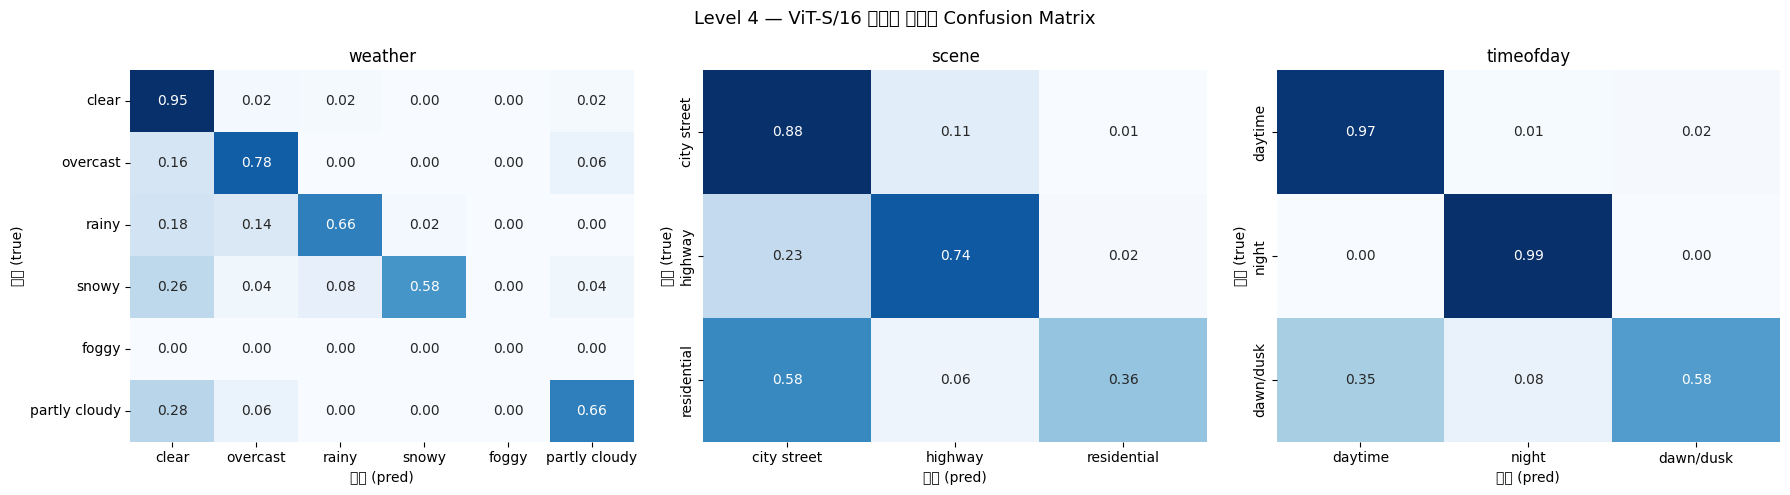


[weather] per-class P/R/F1
  clear          P=0.866 R=0.947 F1=0.904 (support=300)
  overcast       P=0.684 R=0.780 F1=0.729 (support=50)
  rainy          P=0.786 R=0.660 F1=0.717 (support=50)
  snowy          P=0.967 R=0.580 F1=0.725 (support=50)
  foggy          P=0.000 R=0.000 F1=0.000 (support=0)
  partly cloudy  P=0.767 R=0.660 F1=0.710 (support=50)

[scene] per-class P/R/F1
  city street    P=0.808 R=0.882 F1=0.844 (support=306)
  highway        P=0.745 R=0.745 F1=0.745 (support=141)
  residential    P=0.760 R=0.358 F1=0.487 (support=53)

[timeofday] per-class P/R/F1
  daytime        P=0.959 R=0.971 F1=0.965 (support=242)
  night          P=0.979 R=0.991 F1=0.985 (support=232)
  dawn/dusk      P=0.750 R=0.577 F1=0.652 (support=26)


In [6]:
# ============================================================
# 분석 1. 속성별 정규화 Confusion Matrix (best 모델 = ViT-S/16)
# ============================================================
# row 정규화("true") → 각 행이 실제 클래스, 대각선이 recall.
preds, probs, targets, _ = collect_predictions(vit_model, val_loader, device)
print(f"best 모델(ViT) val Avg-MF1 = {average_macro_f1(preds, targets):.4f}")
cms = confusion_matrices(preds, targets, normalize="true")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, a in zip(axes, ATTRIBUTES):
    sns.heatmap(cms[a], annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False,
                xticklabels=CLASS_NAMES[a], yticklabels=CLASS_NAMES[a])
    ax.set_title(f"{a}")
    ax.set_xlabel("예측 (pred)"); ax.set_ylabel("정답 (true)")
fig.suptitle("Level 4 — ViT-S/16 속성별 정규화 Confusion Matrix", fontsize=13)
fig.tight_layout()
plt.show()

# 속성별 per-class P/R/F1 (혼동 클래스 쌍 분석 근거)
prf = per_class_prf(preds, targets)
for a in ATTRIBUTES:
    print(f"\n[{a}] per-class P/R/F1")
    d = prf[a]
    for i, cname in enumerate(d["class"]):
        print(f"  {cname:14s} P={d['precision'][i]:.3f} "
              f"R={d['recall'][i]:.3f} F1={d['f1'][i]:.3f} (support={d['support'][i]})")

showcase val 이미지: [0, 300, 400, 450] weather = ['clear', 'overcast', 'rainy', 'snowy']


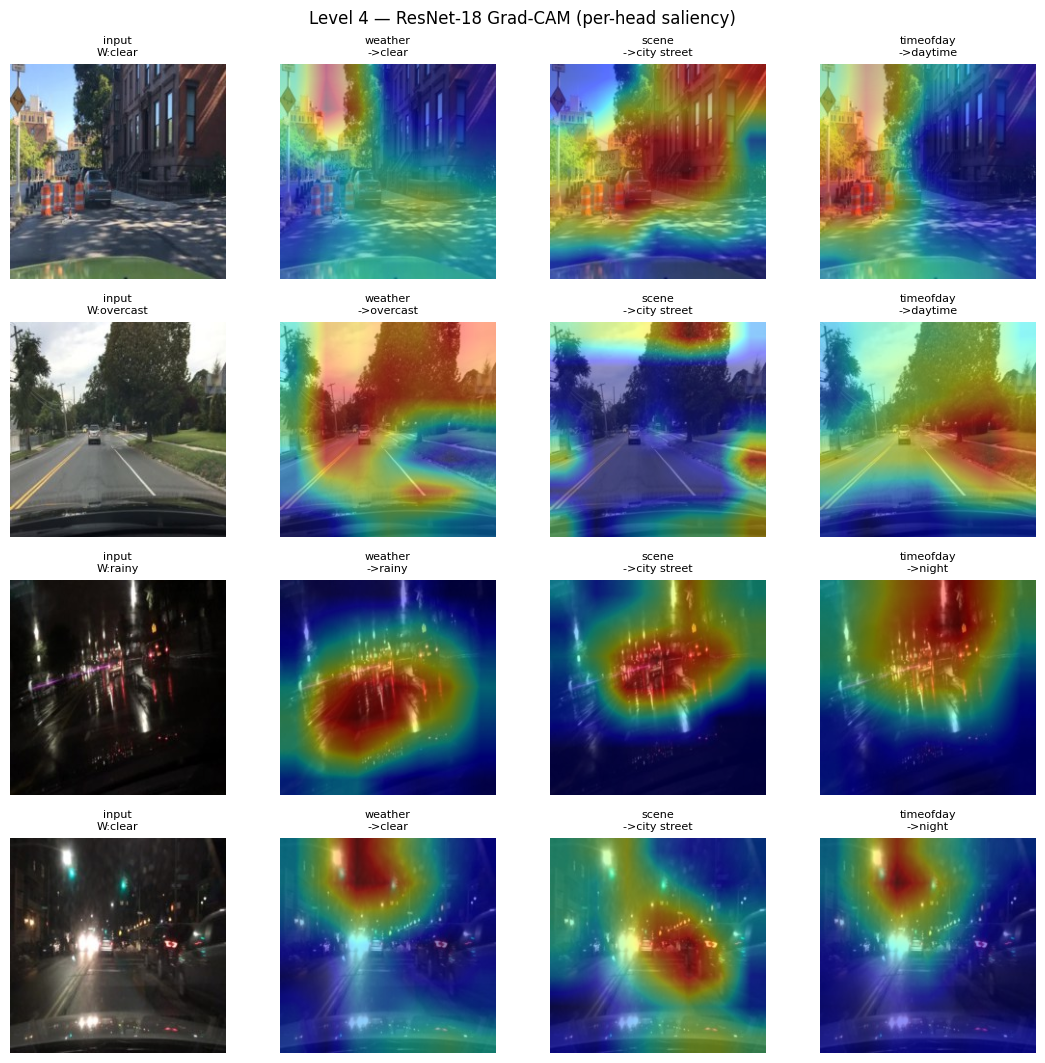

In [7]:
# ============================================================
# 분석 2-a. Grad-CAM — CNN(ResNet-18), head 별 saliency
# ============================================================
# 공유 백본 + head 별 backprop → 같은 이미지에 대해 3개 head 가 각각 어디를 보는지.
MEAN = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
STD  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denorm(x):
    """정규화된 텐서를 [0,1] RGB 이미지로 복원 (시각화용)."""
    img = (x.cpu() * STD + MEAN).clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

def pred_label(out, attr):
    return CLASS_NAMES[attr][int(out[attr].argmax(dim=-1).item())]

def score_fn_for(attr):
    # 해당 head 의 최대 logit 합을 score 로 → 그 head 가 "보는" 영역을 backprop.
    return lambda out, a=attr: out[a].max(dim=-1).values.sum()

# 다양한 날씨(광원/텍스처) 의 대표 val 이미지 선택. foggy 는 train 에 없음.
SHOWCASE_WEATHER = ["clear", "rainy", "snowy", "overcast"]
def pick_images(ds):
    want = {WEATHER_CLASSES.index(c) for c in SHOWCASE_WEATHER}
    chosen, seen = [], set()
    for i in range(len(ds)):
        w = ds.samples[i].weather
        if w in want and w not in seen:
            seen.add(w); chosen.append(i)
        if len(seen) == len(want):
            break
    return chosen or list(range(min(4, len(ds))))

idxs = pick_images(val_ds)
print("showcase val 이미지:", idxs,
      "weather =", [WEATHER_CLASSES[val_ds.samples[i].weather] for i in idxs])

cnn_cam = GradCAM(cnn_model, cnn_model.layer4[-1])   # CNN: 마지막 conv stage
n = len(idxs)
fig, axes = plt.subplots(n, 4, figsize=(11, 2.7 * n)); axes = axes.reshape(n, 4)
for r, idx in enumerate(idxs):
    x = val_ds[idx]["image"].unsqueeze(0).to(device)
    img = denorm(x[0])
    with torch.no_grad():
        out0 = cnn_model(x)
    axes[r, 0].imshow(img)
    axes[r, 0].set_title(f"input\nW:{pred_label(out0,'weather')}", fontsize=8)
    axes[r, 0].axis("off")
    for c, attr in enumerate(ATTRIBUTES, start=1):
        cam = cnn_cam(x, score_fn_for(attr))[0].cpu().numpy()
        axes[r, c].imshow(img); axes[r, c].imshow(cam, cmap="jet", alpha=0.45)
        axes[r, c].set_title(f"{attr}\n->{pred_label(out0,attr)}", fontsize=8)
        axes[r, c].axis("off")
fig.suptitle("Level 4 — ResNet-18 Grad-CAM (per-head saliency)", fontsize=12)
fig.tight_layout(); plt.show()

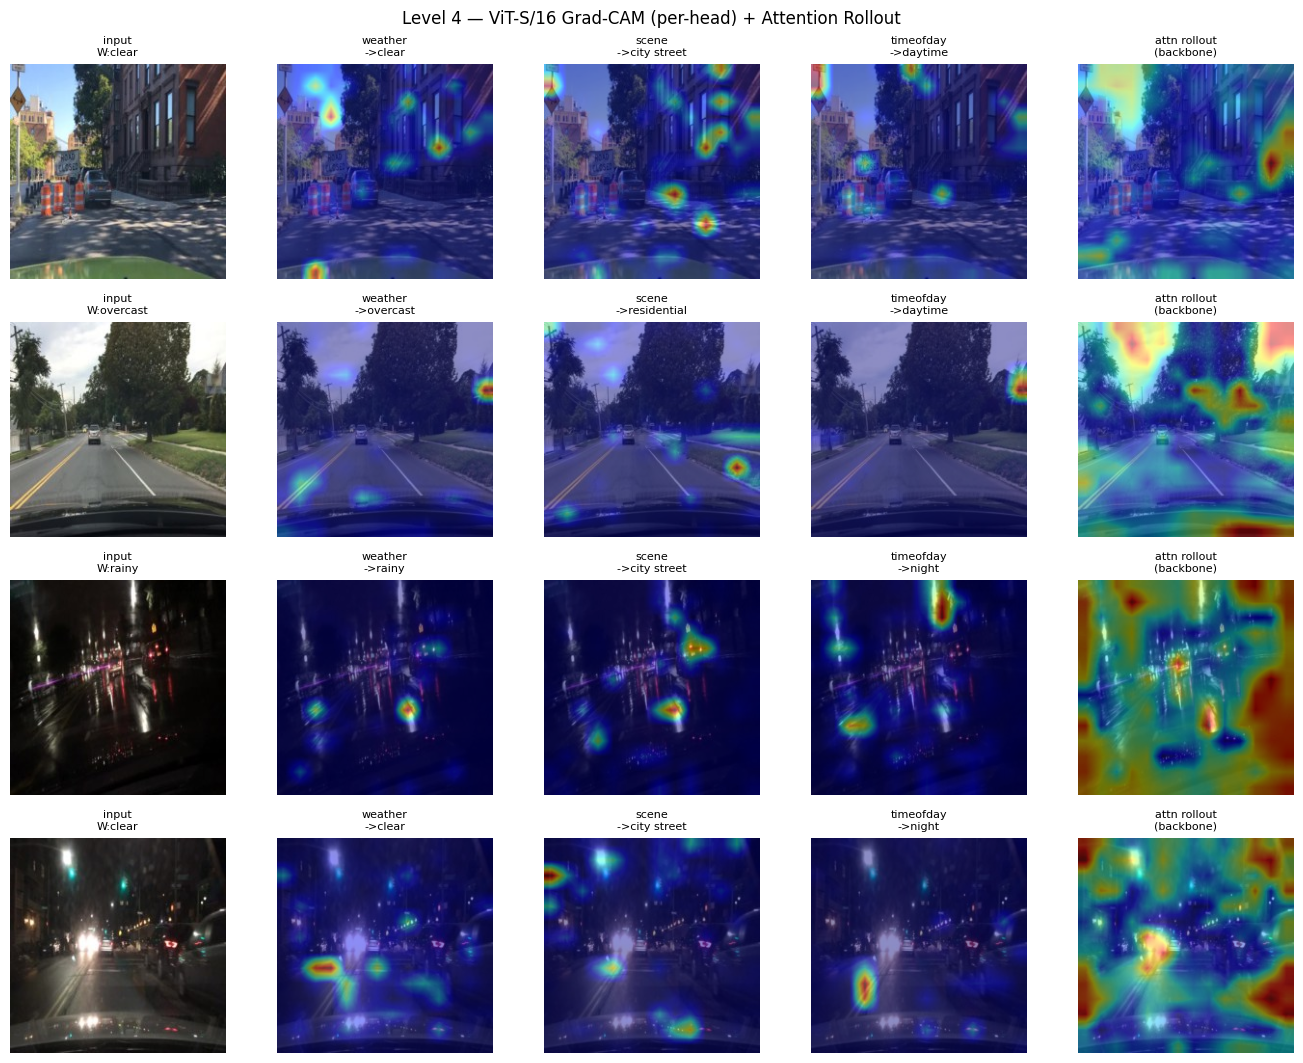

In [8]:
# ============================================================
# 분석 2-b. Grad-CAM — ViT(ViT-S/16) + Attention Rollout
# ============================================================
# CNN(국소적 conv saliency) 대비 ViT(전역 attention) 의 차이를 비교.
# 주의: ViT 는 blocks[-1] 의 patch gradient 가 0 → blocks[-4] 를 target 으로 사용.
vit_cam = ViTGradCAM(vit_model, vit_model.blocks[-4])

fig, axes = plt.subplots(n, 5, figsize=(13.5, 2.7 * n)); axes = axes.reshape(n, 5)
for r, idx in enumerate(idxs):
    x = val_ds[idx]["image"].unsqueeze(0).to(device)
    img = denorm(x[0])
    with torch.no_grad():
        out0 = vit_model(x)
    axes[r, 0].imshow(img)
    axes[r, 0].set_title(f"input\nW:{pred_label(out0,'weather')}", fontsize=8)
    axes[r, 0].axis("off")
    for c, attr in enumerate(ATTRIBUTES, start=1):
        cam = vit_cam(x, score_fn_for(attr))[0].cpu().numpy()
        axes[r, c].imshow(img); axes[r, c].imshow(cam, cmap="jet", alpha=0.45)
        axes[r, c].set_title(f"{attr}\n->{pred_label(out0,attr)}", fontsize=8)
        axes[r, c].axis("off")
    # head-/task-agnostic: 공유 백본이 전체적으로 어디에 attend 하는지
    roll = attention_rollout(vit_model, x)[0].cpu().numpy()
    axes[r, 4].imshow(img); axes[r, 4].imshow(roll, cmap="jet", alpha=0.45)
    axes[r, 4].set_title("attn rollout\n(backbone)", fontsize=8)
    axes[r, 4].axis("off")
fig.suptitle("Level 4 — ViT-S/16 Grad-CAM (per-head) + Attention Rollout", fontsize=12)
fig.tight_layout(); plt.show()

FPS 측정 하드웨어: T4 (채점 유효)

vgg16      Params=134.32M  FLOPs= 30.93G  FPS=  105.6  Avg-MF1=0.5629
resnet18   Params= 11.18M  FLOPs=  3.63G  FPS=  392.3  Avg-MF1=0.6620
resnet50   Params= 23.53M  FLOPs=  8.17G  FPS=  154.2  Avg-MF1=0.6244
vit_s16    Params= 21.67M  FLOPs=  8.48G  FPS=  141.4  Avg-MF1=0.7301


/tmp/ipython-input-9-2052392171.py:57: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipython-input-9-2052392171.py:57: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipython-input-9-2052392171.py:57: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipython-input-9-2052392171.py:57: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.pr

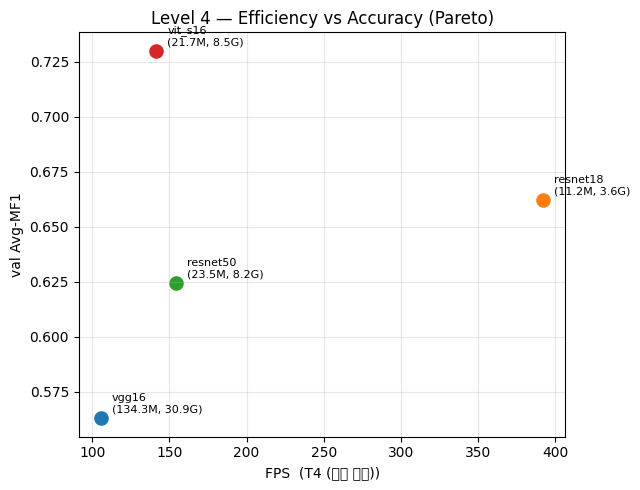

In [9]:
# ============================================================
# 분석 3. Efficiency — Params / FLOPs / FPS  → FPS vs Avg-MF1 Pareto
# ============================================================

import json

MODELS = {"vgg16": VGG16, "resnet18": resnet18,
          "resnet50": resnet50, "vit_s16": vit_small_patch16_224}

def avg_mf1_for(name):
    """저장된 메트릭에서 백본별 best val Avg-MF1 을 읽음 (수치를 지어내지 않음)."""
    if name == "vit_s16":
        p = f"{TBL_DIR}/level3_best_metrics.json"
        if os.path.exists(p):
            return json.load(open(p))["best_val_avg_mf1"]
        p = f"{CKPT_DIR}/level2_vit_pretrained_history.json"
        if os.path.exists(p):
            return max(json.load(open(p))["val_avg_mf1"])
        return None
    p = f"{CKPT_DIR}/level1_{name}_history.json"
    if os.path.exists(p):
        return max(json.load(open(p))["val_avg_mf1"])
    return None

hw = "T4 (채점 유효)" if device.type == "cuda" else f"{device.type} (참고용)"
print(f"FPS 측정 하드웨어: {hw}\n")

rows = []
for name, fn in MODELS.items():
    m = fn().to(device).eval()
    params = count_parameters(m)
    flops, _ = count_flops(m, device)
    fps = measure_fps(m, device, batch_size=1, n_warmup=20, n_iter=200)
    mf1 = avg_mf1_for(name)
    rows.append({"name": name, "params_M": params / 1e6, "gflops": flops / 1e9,
                 "fps": fps, "avg_mf1": mf1})
    mf1s = "—" if mf1 is None else f"{mf1:.4f}"
    print(f"{name:10s} Params={params/1e6:6.2f}M  FLOPs={flops/1e9:6.2f}G  "
          f"FPS={fps:7.1f}  Avg-MF1={mf1s}")
    del m
    if device.type == "cuda":
        torch.cuda.empty_cache()

# --- FPS vs Avg-MF1 Pareto plot ---
pts = [r for r in rows if r["avg_mf1"] is not None]
if pts:
    fig, ax = plt.subplots(figsize=(6.5, 5))
    for r in pts:
        ax.scatter(r["fps"], r["avg_mf1"], s=90)
        ax.annotate(f"{r['name']}\n({r['params_M']:.1f}M, {r['gflops']:.1f}G)",
                    (r["fps"], r["avg_mf1"]), textcoords="offset points",
                    xytext=(8, 4), fontsize=8)
    ax.set_xlabel(f"FPS  ({hw})")
    ax.set_ylabel("val Avg-MF1")
    ax.set_title("Level 4 — Efficiency vs Accuracy (Pareto)")
    ax.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()